In [1]:
import gc
import argparse
import yaml

import matplotlib.pyplot as plt
import numpy as np

from datatree import open_datatree
from scipy.stats import describe

from var_assim.plotting.presets import get_presets
from var_assim.plotting.filtering import filter_by_max_conceivable, filter_datatree_by_cost_ratio_memeff
from var_assim.plotting.pproc import get_angle_r2
from var_assim.plotting.utils import make_figure_filename
from var_assim.config import PRIOR_PATH, NOISE_PATH, TRUTH_PATH, WINDOW_PATH, DATA_DIR_ABS, FIGS_DIR
from var_assim.calibration.priors import ClimateModelPriors
from var_assim.calibration.noise import ClimateModelNoise
from var_assim.calibration.truth import ClimateModelTruth
from var_assim.calibration.windowing import AssimilationWindowing

presets, _ = get_presets()
plt.rcParams.update(presets)

# enable auto reload
%load_ext autoreload
%autoreload 2

In [2]:
presets, basefile = get_presets()
plt.rcParams.update(presets)
SAVE_FIGS = True

# CHECKING NEW PRIOR FRAMEWORK WORKS

In [3]:
dt = open_datatree(DATA_DIR_ABS / 'output' / 'pco2geowc' / 'var-assim-output_ssp245_pco2geowc_four_AR1_TMIN2025_THETA15_ECS3.0_DEGpDEC0.1_NYRSRAMP50_Nens5.nc')
dt

DataTree('None', parent=None)
├── DataTree('2040')
│       Dimensions:         (ens_mem: 5, vari: 31, time: 16, iter: 101, obs_var: 4)
│       Coordinates:
│         * time            (time) int64 2025 2026 2027 2028 ... 2037 2038 2039 2040
│         * iter            (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
│         * vari            (vari) object 'T1' 'T2' 'Q' 'T_R1' ... 'q13' 'q14' 'q15'
│         * ens_mem         (ens_mem) int64 0 1 2 3 4
│         * obs_var         (obs_var) object 'T1' 'Q' 'T_R1' 'T_R2'
│       Data variables:
│           data_final      (ens_mem, vari, time) float64 ...
│           l2s             (ens_mem) float64 ...
│           costs           (ens_mem) float64 ...
│           controls        (ens_mem, vari) float64 ...
│           data_hist       (ens_mem, vari, iter, time) float64 ...
│           l2_hist         (ens_mem, iter) float64 ...
│           cost_hist       (ens_mem, iter) float64 ...
│           controls_hist   (ens_mem, vari, iter) float64 ...
│           flag            (ens_mem) int64 ...
│           obs             (obs_var, time) float64 ...
│           data_truth      (vari, time) float64 ...
│           controls_truth  (vari) float64 ...
│       Attributes: (12/18)
│           reg_noise:         False
│           model:             pco2geowc
│           tol:               0.01
│           debug:             False
│           n_yrs_ramp:        50
│           tmin:              2025
│           ...                ...
│           run_time:          8.546504974365234
│           command:           /project/bbcael/ambauer/envs/var_assim_sai/bin/var-ass...
│           noise_model:       AR1
│           max_iter:          100
│           windowing:         four
│           scenario:          ssp245
├── DataTree('2060')
│       Dimensions:         (ens_mem: 5, vari: 51, time: 36, iter: 101, obs_var: 4)
│       Coordinates:
│         * time            (time) int64 2025 2026 2027 2028 ... 2057 2058 2059 2060
│         * iter            (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
│         * vari            (vari) object 'T1' 'T2' 'Q' 'T_R1' ... 'q33' 'q34' 'q35'
│         * ens_mem         (ens_mem) int64 0 1 2 3 4
│         * obs_var         (obs_var) object 'T1' 'Q' 'T_R1' 'T_R2'
│       Data variables:
│           data_final      (ens_mem, vari, time) float64 ...
│           l2s             (ens_mem) float64 ...
│           costs           (ens_mem) float64 ...
│           controls        (ens_mem, vari) float64 ...
│           data_hist       (ens_mem, vari, iter, time) float64 ...
│           l2_hist         (ens_mem, iter) float64 ...
│           cost_hist       (ens_mem, iter) float64 ...
│           controls_hist   (ens_mem, vari, iter) float64 ...
│           flag            (ens_mem) int64 ...
│           obs             (obs_var, time) float64 ...
│           data_truth      (vari, time) float64 ...
│           controls_truth  (vari) float64 ...
│       Attributes: (12/18)
│           reg_noise:         False
│           model:             pco2geowc
│           tol:               0.01
│           debug:             False
│           n_yrs_ramp:        50
│           tmin:              2025
│           ...                ...
│           run_time:          6.259100675582886
│           command:           /project/bbcael/ambauer/envs/var_assim_sai/bin/var-ass...
│           noise_model:       AR1
│           max_iter:          100
│           windowing:         four
│           scenario:          ssp245
├── DataTree('2080')
│       Dimensions:         (ens_mem: 5, vari: 71, time: 56, iter: 101, obs_var: 4)
│       Coordinates:
│         * time            (time) int64 2025 2026 2027 2028 ... 2077 2078 2079 2080
│         * iter            (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
│         * vari            (vari) object 'T1' 'T2' 'Q' 'T_R1' ... 'q53' 'q54' 'q55'
│         * ens_mem         (ens_mem) int64 0 1 2 3 4
│         * 

In [14]:
priors = []
for wind in ['2040', '2060', '2080', '2100']:
    priors.append(np.sort(dt[wind].ds.controls_hist.sel(vari='G', iter=0).values))

In [15]:
priors

[array([0.08448934, 0.29201767, 0.42924414, 0.92622831, 1.12169409]),
 array([0.08448934, 0.29201767, 0.42924414, 0.92622831, 1.12169409]),
 array([0.08448934, 0.29201767, 0.42924414, 0.92622831, 1.12169409]),
 array([0.08448934, 0.29201767, 0.42924414, 0.92622831, 1.12169409])]

# PRIOR BUG? KINKS AT 2050 FOR ALL SIMULATIONS

In [6]:
# properties that change across models
panel_configs = {
    'pco2geowc_ssp245_ar1': {
        'prefix': 'var-assim-output',
        'ssp': 'ssp245',
        'model': 'pco2geowc',
        'noise_model': 'AR1',
        'degpdec': 0.1
    },

    'pco2geowc_ssp585_ar1': {
        'prefix': 'var-assim-output',
        'ssp': 'ssp585',
        'model': 'pco2geowc',
        'noise_model': 'AR1',
        'degpdec': 0.1
    },

    'pco2geowc_ssp245_ar1_higeo': {
        'prefix': 'var-assim-output',
        'ssp': 'ssp245',
        'model': 'pco2geowc',
        'noise_model': 'AR1',
        'degpdec': 0.2
    },

    'pco2geowc_nn_ssp245': {
        'prefix': 'var-assim-output',
        'ssp': 'ssp245',
        'model': 'pco2geowc_nn',
        'noise_model': 'nn',
        'degpdec': 0.1
    },
}

# properties that are constant across models
angles_file = ['5', '11', '15', '21', '30', '35']
reg_noise = False
ECS = 3.0
NYRSRAMP = 50
windowing_config = 'ws_gradual'
Nens = 1000
TMIN = 2023
ANGLE_MAX_CONCEIVABLE = 60.

# get the assimilation windows for this config
with open(WINDOW_PATH) as f:
    window_config = yaml.safe_load(f)

windows = window_config[windowing_config]['windows']

windows

[2025, 2030, 2035, 2040, 2050, 2060, 2075, 2100]

In [7]:
# empty lists for filling later
angles = np.zeros((len(panel_configs), len(angles_file), len(windows), Nens))
angles_tr = np.zeros(len(angles_file))
angles_prior = np.zeros(Nens)

WINDOW_TO_ANALYZE = '2050'  # the one with the kink
datasets = {config: [] for config in panel_configs.keys()}  # list of datasets at 2050 assim window
angles_hist = {config: [] for config in panel_configs.keys()}  # list of history of angle parameter estimation

datasets

{'pco2geowc_ssp245_ar1': [],
 'pco2geowc_ssp585_ar1': [],
 'pco2geowc_ssp245_ar1_higeo': [],
 'pco2geowc_nn_ssp245': []}

In [8]:
for idx, config in enumerate(panel_configs.keys()):
    # store config as local variables
    prefix = panel_configs[config]['prefix']
    ssp = panel_configs[config]['ssp']
    model = panel_configs[config]['model']
    noise_model = panel_configs[config]['noise_model']
    DEGpDEC = panel_configs[config]['degpdec']

    angles_hist_config = []

    for angx, th in enumerate(angles_file):
        angles_angle = []
        # make temporary CLI namespace for processing
        cli_args = argparse.Namespace(
            model=model,
            ssp=ssp,
            noise_model=noise_model,
            tmin=TMIN,
            theta=float(th),
            AR=1 if model != 'pco2geowc_nn' else None,
            ecs=ECS,
            DEGpDEC=DEGpDEC,
            NYRSRAMP=NYRSRAMP,
            Nens=Nens,
            reg_noise=reg_noise,
            windowing=windowing_config
        )

        # setup data classes
        Noise = ClimateModelNoise.from_cli_and_yaml(cli_args, NOISE_PATH)
        Prior = ClimateModelPriors.from_cli_and_yaml_and_noise(cli_args, PRIOR_PATH, Noise)
        Windowing = AssimilationWindowing.from_cli_and_yaml(cli_args, WINDOW_PATH)
        Truth = ClimateModelTruth.from_cli_and_yaml(cli_args, TRUTH_PATH)

        # compute true value of angle
        if idx == 0:
            angles_tr[angx] = get_angle_r2(
                Truth.ALPHA_TR[0], Truth.ALPHA_TR[1],
                Truth.BETA_TR[0], Truth.BETA_TR[1],
                Truth.L_TR, Truth.EPS_TR, Truth.G_TR
                )
            if idx == 1:
                print(f"True values of the theta parameter are: {angles_tr}")

        # import data
        fname = DATA_DIR_ABS / "output" / model / (
                f"{prefix}_{ssp}_{model}_{windowing_config}_{noise_model}_TMIN{TMIN}_THETA{th}_ECS{ECS}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nens{Nens}.nc"
            )

        ## variables we need for analysis (only do for first run through, constant across configs)
        if idx == 0 and angx == 0:
            dt_meta = open_datatree(fname, engine='netcdf4')
            relevant_vars = ['cost_hist', 'controls', 'controls_hist']
            dropped_vars = [v for v in dt_meta[str(windows[0])].ds.data_vars if v not in relevant_vars]
            # dt_meta.close()

        # open and clean dataset
        dt = open_datatree(fname, engine='netcdf4', drop_variables=dropped_vars)
        dt_clean = filter_datatree_by_cost_ratio_memeff(dt, threshold=1e-2, clear_after_each_node=True)

        datasets[config].append(dt_clean[WINDOW_TO_ANALYZE].ds)

        # make priors (only have to do once)
        if idx == 0 and angx == 0:
            prior_a1 = dt[str(windows[0])].ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
            prior_b1 = dt[str(windows[0])].ds.controls_hist.sel(vari='BETA_R1', iter=0).values
            prior_a2 = dt[str(windows[0])].ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
            prior_b2 = dt[str(windows[0])].ds.controls_hist.sel(vari='BETA_R2', iter=0).values
            prior_l = dt[str(windows[0])].ds.controls_hist.sel(vari='L', iter=0).values
            prior_g = dt[str(windows[0])].ds.controls_hist.sel(vari='G', iter=0).values
            prior_eps = dt[str(windows[0])].ds.controls_hist.sel(vari='EPS', iter=0).values

            for i in range(Nens):
                angles_prior[i] = get_angle_r2(prior_a1[i], prior_a2[i],
                                               prior_b1[i], prior_b2[i],
                                               prior_l[i], prior_eps[i], prior_g[i])
            
            print("Angle prior summary statistics:")
            for key, value in describe(angles_prior)._asdict().items():
                print(f"{key:>10}: {value}")

        # compute angles
        winds = np.array([w[1] for w in Windowing.windows])
        windss = [str(w) for w in winds]

        for w_, w in enumerate(windss):
            tmp_a1 = dt_clean[w].ds.controls.sel(vari='ALPHA_R1').values
            tmp_a2 = dt_clean[w].ds.controls.sel(vari='ALPHA_R2').values
            tmp_b1 = dt_clean[w].ds.controls.sel(vari='BETA_R1').values
            tmp_b2 = dt_clean[w].ds.controls.sel(vari='BETA_R2').values
            tmp_l = dt_clean[w].ds.controls.sel(vari='L').values
            tmp_g = dt_clean[w].ds.controls.sel(vari='G').values
            tmp_eps = dt_clean[w].ds.controls.sel(vari='EPS').values
            for i in range(Nens):
                angles[idx, angx, w_, i] = get_angle_r2(tmp_a1[i], tmp_a2[i],
                                                        tmp_b1[i], tmp_b2[i], 
                                                        tmp_l[i], tmp_eps[i], tmp_g[i])
                
        # loop through and make the angle parameter distribution as it evolves over each iteration
        for iter in range(len(dt_clean[WINDOW_TO_ANALYZE].ds.iter.values)):
            tmp_angles = []
            tmp_a1 = dt_clean[WINDOW_TO_ANALYZE].ds.controls_hist.sel(vari='ALPHA_R1', iter=iter).values
            tmp_a2 = dt_clean[WINDOW_TO_ANALYZE].ds.controls_hist.sel(vari='ALPHA_R2', iter=iter).values
            tmp_b1 = dt_clean[WINDOW_TO_ANALYZE].ds.controls_hist.sel(vari='BETA_R1', iter=iter).values
            tmp_b2 = dt_clean[WINDOW_TO_ANALYZE].ds.controls_hist.sel(vari='BETA_R2', iter=iter).values
            tmp_l = dt_clean[WINDOW_TO_ANALYZE].ds.controls_hist.sel(vari='L', iter=iter).values
            tmp_g = dt_clean[WINDOW_TO_ANALYZE].ds.controls_hist.sel(vari='G', iter=iter).values
            tmp_eps = dt_clean[WINDOW_TO_ANALYZE].ds.controls_hist.sel(vari='EPS', iter=iter).values
            for i in range(Nens):
                tmp_angle = get_angle_r2(tmp_a1[i], tmp_a2[i],
                                        tmp_b1[i], tmp_b2[i], 
                                        tmp_l[i], tmp_eps[i], tmp_g[i])
                tmp_angles.append(tmp_angle[0])
            
            angles_angle.append(tmp_angles)

        # cleanup
        for node in dt.subtree:
            if node.ds is not None:
                node.ds.close()

        del dt
        gc.collect()

        angles_hist_config.append(angles_angle)
    
    angles_hist[config].append(angles_hist_config)
                
angles_filtered = filter_by_max_conceivable(angles, ANGLE_MAX_CONCEIVABLE)


Found 9 nodes in tree
Processing node 1: /2025
  Memory: 14.8 MB
  Result: 996 kept, 4 filtered
Processing node 2: /2030
  Memory: 18.7 MB
  Result: 997 kept, 3 filtered
Processing node 3: /2035
  Memory: 22.6 MB
  Result: 996 kept, 4 filtered
Processing node 4: /2040
  Memory: 26.5 MB
  Result: 993 kept, 7 filtered
Processing node 5: /2050
  Memory: 34.2 MB
  Result: 989 kept, 11 filtered
Processing node 6: /2060
  Memory: 42.0 MB
  Result: 990 kept, 10 filtered
Processing node 7: /2075
  Memory: 53.7 MB
  Result: 990 kept, 10 filtered
Processing node 8: /2100
  Memory: 73.2 MB
  Result: 989 kept, 11 filtered

Rebuilding tree with 8 filtered nodes...
✓ Filtering complete
Angle prior summary statistics:
      nobs: 1000
    minmax: (0.1929478166199524, 53.38434662725551)
      mean: 16.328771238020902
  variance: 67.09245391316404
  skewness: 0.5892057417817687
  kurtosis: 0.5747406743255792
Found 9 nodes in tree
Processing node 1: /2025
  Memory: 14.8 MB
  Result: 996 kept, 4 filtered

In [9]:
angles_hist_np = {config: np.array(angles_hist[config])[0] for config in panel_configs.keys()}

angles_hist_np['pco2geowc_nn_ssp245'].shape

(6, 101, 1000)

fig saved to: /project/bbcael/ambauer/learning_sai/analysis/figs/debug/2026-06-18-2050_dist_evos.png


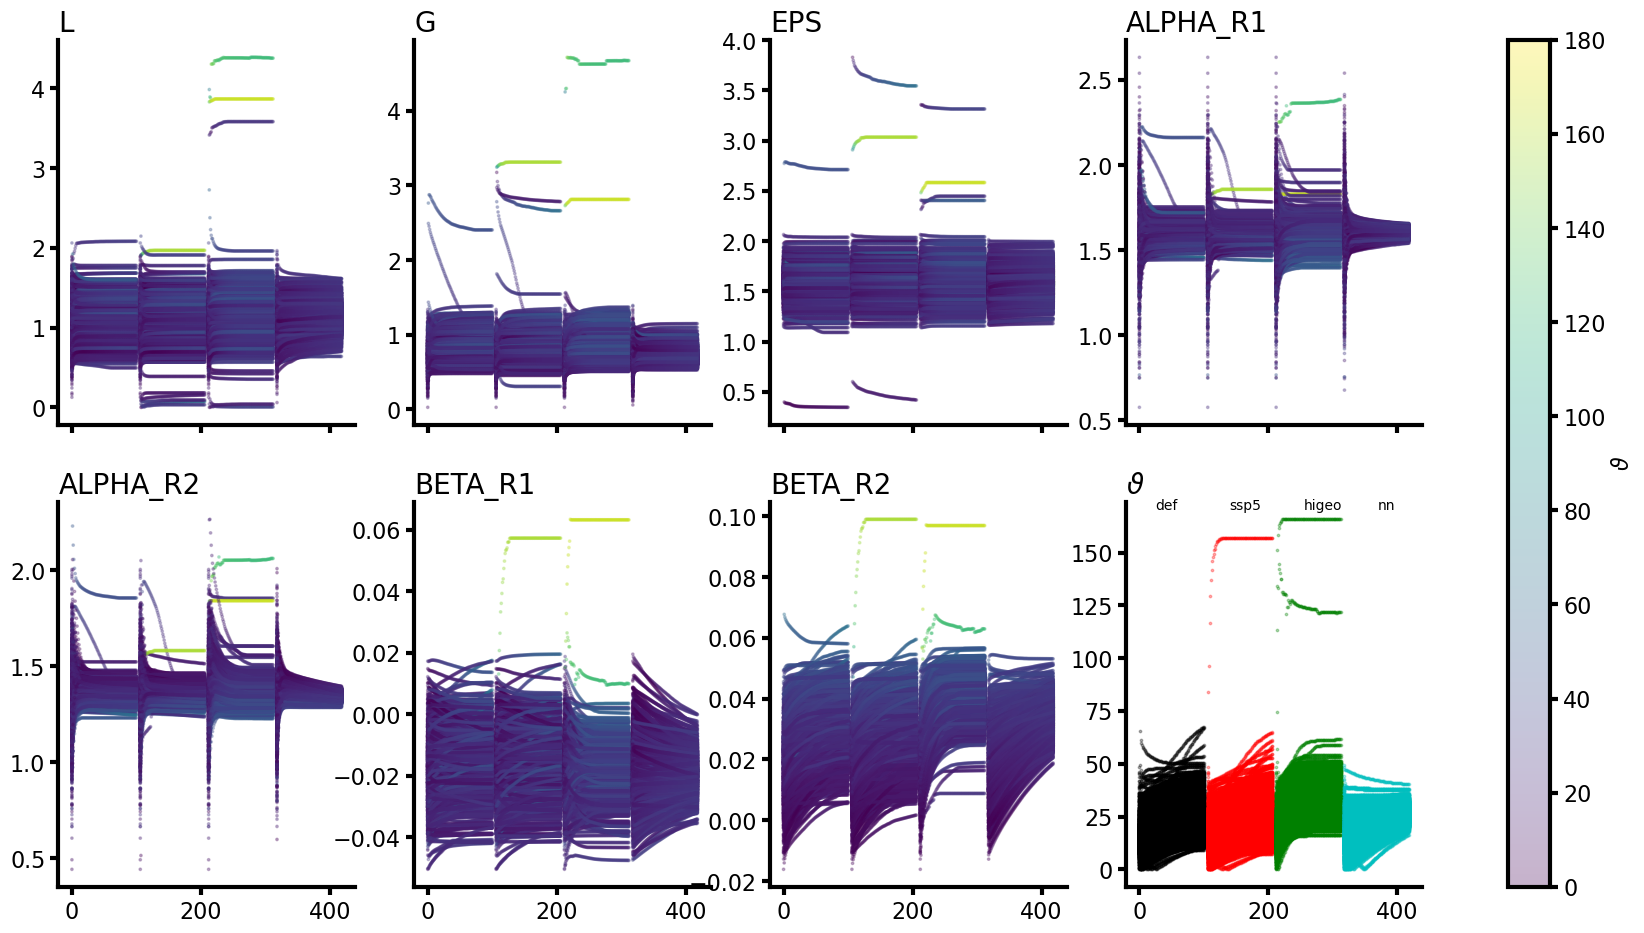

In [17]:
angle_rel_vars = ['L', 'G', 'EPS', 'ALPHA_R1', 'ALPHA_R2', 'BETA_R1', 'BETA_R2']
PLOTTING_GAP = 5
ANGLE_IND = -1

config_colors = ['k', 'r', 'g', 'c']

fig, axs = plt.subplots(2, 4, figsize=(22, 11), sharex=True)

for idx, config in enumerate(panel_configs.keys()):
    # Angle data with shape (n_ens, n_iter)
    angle_data = angles_hist_np[config][ANGLE_IND].T

    for var, ax in zip(angle_rel_vars, axs.flatten()):
        data = datasets[config][ANGLE_IND].controls_hist.sel(vari=var).values
        n_ens, n_iter = data.shape

        x_vals = np.tile(np.arange(n_iter), n_ens)
        x_vals_shift = x_vals + idx * (n_iter + PLOTTING_GAP)

        y_vals = data.ravel()

        # Color each point by its corresponding angle
        angle_vals = angle_data.ravel()

        sc = ax.scatter(
            x_vals_shift,
            y_vals,
            c=angle_vals,
            s=3,
            alpha=0.3,
            cmap="viridis",   # choose any matplotlib colormap
            vmin=0,           # optional: fix color scale
            vmax=180,         # optional: adjust to your angle range
        )

for idx, config in enumerate(panel_configs.keys()):
    data = angles_hist_np[config][ANGLE_IND].T
    n_ens, n_iter = data.shape

    x_vals = np.tile(np.arange(n_iter), n_ens)
    x_vals_shift = x_vals + idx * (n_iter + PLOTTING_GAP)  # shift data slightly for each experiment

    y_vals = data.ravel()
    # y_vals = np.where(y_vals <= 70, y_vals, np.nan)

    axs[1, 3].scatter(x_vals_shift, y_vals, s=3, alpha=0.3, label=config, color=config_colors[idx])

for ax, title in zip(axs.flatten(), angle_rel_vars):
    ax.set_title(title)

labels = ['def', 'ssp5', 'higeo', 'nn']
for idx, label in enumerate(labels):
    axs[1, 3].text(0.25 * idx + 0.1, 0.98, label, transform=axs[1, 3].transAxes, fontsize=10)

axs[1, 3].set_title(r"$\vartheta$")

fig.colorbar(sc, ax=axs, label=r'$\vartheta$')
# fig.tight_layout()

if SAVE_FIGS:
    fig.savefig(make_figure_filename(f'{WINDOW_TO_ANALYZE}_dist_evos', FIGS_DIR / 'debug'), bbox_inches='tight')
    print(f"fig saved to: {make_figure_filename(f'{WINDOW_TO_ANALYZE}_dist_evos', FIGS_DIR / 'debug')}")

plt.show()

In [12]:
qs = [f'q{i}' for i in range(28)]

for config in panel_configs.keys():
    if 'nn' not in config:
        ds = datasets[config][ANGLE_IND]
        ds_mean = ds.mean(dim='ens_mem')
        time_mean_qs = ds.sel(vari=qs).mean(dim=['vari', 'ens_mem']).controls.values
        time_med_qs = ds.sel(vari=qs).median(dim=['vari', 'ens_mem']).controls.values
        time_std_qs = ds.sel(vari=qs).std(dim=['vari', 'ens_mem']).controls.values
        time_max_qs = ds.sel(vari=qs).max(dim=['vari', 'ens_mem']).controls.values
        time_min_qs = ds.sel(vari=qs).min(dim=['vari', 'ens_mem']).controls.values
        print(f"CONFIG: {config} | mean = {time_mean_qs}, median = {time_med_qs}, time_std_qs = {time_std_qs}")
        for t, q in enumerate(qs):
            data = ds.controls.sel(vari=q).values
            print(f"    > t = {2023 + t} | mean = {np.nanmean(data)}, median = {np.nanmedian(data)}, 5th percentile = {np.nanpercentile(data, 5)}, 95th percentile = {np.nanpercentile(data, 95)}, max = {np.nanmax(data)}, min = {np.nanmin(data)}")



CONFIG: pco2geowc_ssp245_ar1 | mean = -0.008864494182006471, median = -0.006587899479952787, time_std_qs = 0.2575739755526605
    > t = 2023 | mean = -0.05083000303648562, median = -0.05171860420121423, 5th percentile = -0.4475795907658101, 95th percentile = 0.3487309578659111, max = 0.6920863018181497, min = -0.9747605336488543
    > t = 2024 | mean = -0.22835406955762172, median = -0.23449162527975825, 5th percentile = -0.6936593402428806, 95th percentile = 0.23698822622897114, max = 0.7144339921086997, min = -0.9999655889286225
    > t = 2025 | mean = -0.2341090255882995, median = -0.24487096010318443, 5th percentile = -0.6175349239295613, 95th percentile = 0.1414355061770045, max = 0.5863648143050314, min = -0.8740823602995884
    > t = 2026 | mean = -0.002702244709436016, median = -0.012341858188576266, 5th percentile = -0.3827192851968422, 95th percentile = 0.3797876393349798, max = 0.7562074105257308, min = -0.8134476527685532
    > t = 2027 | mean = 0.01261001020305769, median 